In [1]:
import pandas as pd
import numpy as np

housing_prices = pd.read_csv("/content/work/housing_prices.txt", header=None)
# rename columns
housing_prices.columns = ["Population_in_10k", "Price_in_10k"]
print(housing_prices)

X = np.asarray(housing_prices.Population_in_10k)
y = np.asarray(housing_prices.Price_in_10k)

    Population_in_10k  Price_in_10k
0              6.1101      17.59200
1              5.5277       9.13020
2              8.5186      13.66200
3              7.0032      11.85400
4              5.8598       6.82330
..                ...           ...
92             5.8707       7.20290
93             5.3054       1.98690
94             8.2934       0.14454
95            13.3940       9.05510
96             5.4369       0.61705

[97 rows x 2 columns]


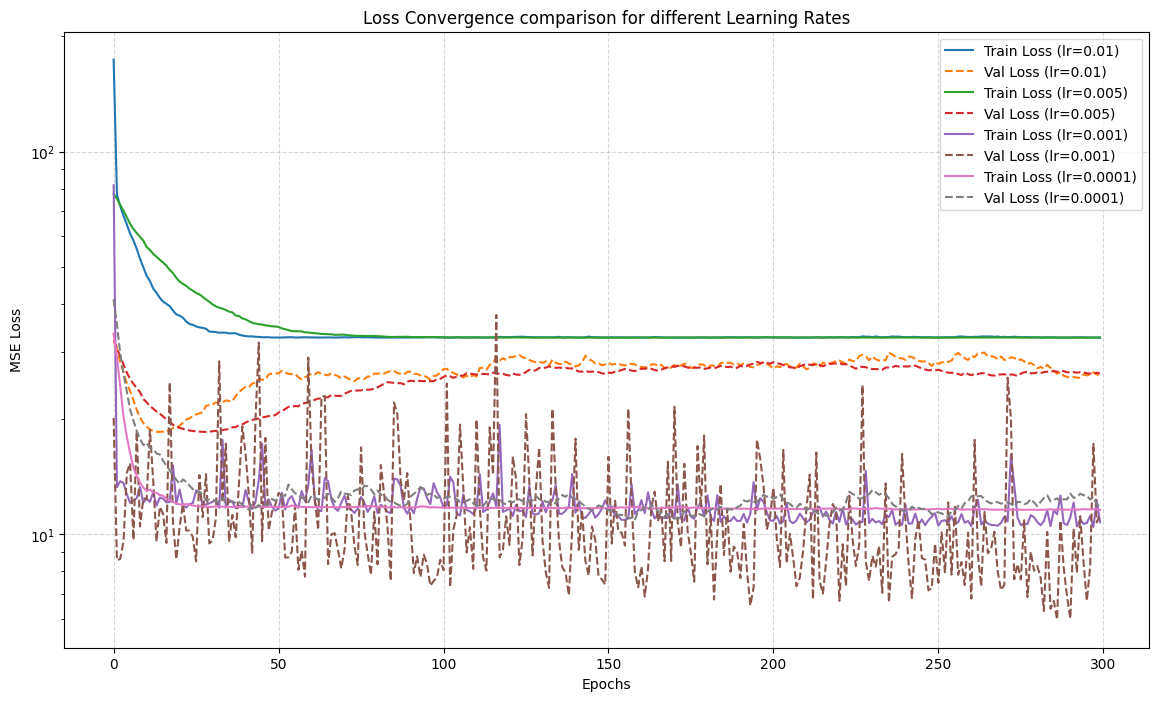

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

# We will test a range of learning rates to observe convergence behavior
learning_rates = [0.01, 0.005, 0.001, 0.0001]
epochs = 300

plt.figure(figsize=(14, 8))

for lr in learning_rates:
    # Rebuild the same architecture to ensure fresh weights
    model_sweep = tf.keras.Sequential([
        tf.keras.layers.Input((1,)),
        tf.keras.layers.Dense(2, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    optimizer = tf.keras.optimizers.SGD(learning_rate=lr)
    model_sweep.compile(optimizer=optimizer, loss='mse')

    # Train the model
    history_sweep = model_sweep.fit(X, y, epochs=epochs, validation_split=0.3, verbose=0)

    # Plot training and validation curves
    plt.plot(history_sweep.history['loss'], label=f'Train Loss (lr={lr})')
    plt.plot(history_sweep.history['val_loss'], linestyle='--', label=f'Val Loss (lr={lr})')

plt.title('Loss Convergence comparison for different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.yscale('log') # Log scale helps view differences clearly if losses vary widely
plt.show()

# Analysis of loss curves for different learning rates and epochs.

1. Learning rate
    - `lr = 0.01` and `lr = 0.005` (Blue/Orange and Green/Red curves): These learning rates are too high. The cause validation loss to diverge and stagnate at a much higher loss level ~ 20-30
    - `lr = 0.001` (Purple and Borwn curves): This learning rate causes the validation loss to oscillate too much. This indicates that the predictions are constantly driving the weights and biases away from the optimal solution.
    - `lr = 0.0001` (Pink and Grey curves): This is the most stable learning rate. Both training and validation losses appear to converge together to the lowest overall stable loss around 11-12 with minimal fluctuation compared to other curves.
2. Ideal epochs: Using the stable LR of 0.0001, the loss decreases rapidly in the first 50-100 epochs. After 150 epochs, both curves flatten completely.

Based on this, I use lr=0.0001 and n_epochs=180

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Price of house in city with population 165,000 is $[145998.75]


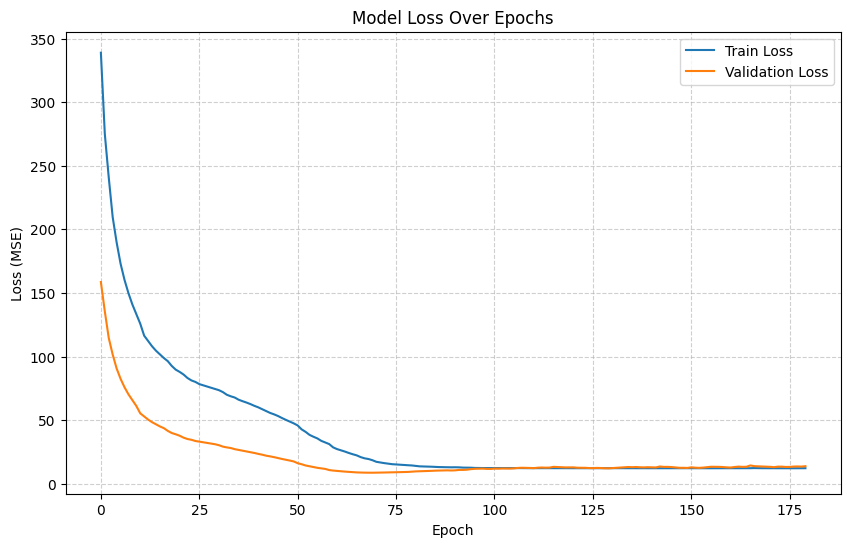

In [10]:
good_lr = 0.0001
good_n_epochs = 180

import tensorflow as tf

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input((1,)))
model.add(tf.keras.layers.Dense(2, activation='relu'))
model.add(tf.keras.layers.Dense(1))
optimizer = tf.keras.optimizers.SGD(learning_rate=good_lr)
loss_fn = tf.keras.losses.MeanSquaredError()

model.compile(optimizer=optimizer, loss=loss_fn)
history = model.fit(X, y, epochs=good_n_epochs, validation_split=0.3, verbose=0)

print(f"Price of house in city with population 165,000 is ${model.predict(np.array([165_000 / 10_000]))[0]*10_000}")

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()